# Rogers et al. (2004): semantic memory and deterioration

**A PyTorch mechanism reconstruction, not an exact recovery of the published curves.**

The recurrent network learns mappings among names, verbal descriptors and visual features. After training, connections are removed without retraining; the same damaged model is tested in naming, sorting, word-picture matching and drawing/delayed copying.


Sources: [paper](https://doi.org/10.1037/0033-295X.111.1.205), [author lab RBP documentation](https://web.stanford.edu/group/pdplab/pdphandbookV3/handbookch9.html).

The next cell contains the complete implementation so this notebook can run independently. Dependencies: `torch`, `numpy`, `matplotlib`, `scipy`. CPU execution; no GPU required.

In [1]:
"""PyTorch reconstruction of Rogers et al. (2004), not original author code.

All matrices use [receiver, sender]. No lesion rescaling or lesion retraining.
"""
from __future__ import annotations

import argparse
import csv
import hashlib
import json
import time
from pathlib import Path

import numpy as np
import torch
from torch import Tensor, nn

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "website").is_dir() and (p / "notebooks").is_dir()), Path.cwd())
VISIBLE, HIDDEN, TOTAL = 216, 64, 280
CATEGORIES = ['bird', 'mammal', 'vehicle', 'household', 'tool', 'fruit']
GENERAL = {0: [0], 1: [0, 1], 2: [2], 3: [4]}


def make_environment(seed: int = 2004) -> dict:
    """Seeded reconstruction of pp. 212-214; not the unavailable original vectors.

    p=.8 for prototype properties, .2 for eligible distinctive properties, zero
    for excluded properties. Reserved verbal labels are exact, as in p. 213.
    Fruit visual prototype follows the prose where Figure 3 is inconsistent.
    """
    rng = np.random.default_rng(seed)
    visual_p = np.zeros((6, 64))
    visual_p[:2, :32] = .2
    visual_p[:2, :8] = .8
    visual_p[0, 8:14] = .8
    visual_p[1, 14:20] = .8
    visual_p[2:, 32:] = .2
    visual_p[2:5, 32:34] = .8
    visual_p[2, 34:38] = .8
    visual_p[4, 38:42] = .8
    visual_p[5, [32, 38, 61, 62, 63]] = .8

    verbal_p = np.zeros((6, 112))
    verbal_p[:2, :32] = .2
    verbal_p[:2, :5] = .8
    verbal_p[0, 5:10] = .8
    verbal_p[1, 10:15] = .8
    verbal_p[2:5, 32:64] = .2
    verbal_p[2:5, 32] = .8
    verbal_p[2, 33:37] = .8
    verbal_p[5, :64] = .2
    verbal_p[5, :15] = 0
    verbal_p[5, [5, 32]] = .8
    verbal_p[5, 33:37] = 0
    verbal_p[:2, 64:80] = .2
    verbal_p[:2, 64:67] = .8
    verbal_p[0, 67:70] = .8
    verbal_p[1, 70:72] = .8
    verbal_p[2:5, 80:96] = .2
    verbal_p[2:5, 80] = .8
    verbal_p[2, 81:83] = .8
    verbal_p[4, 82] = .8
    verbal_p[5, 64:96] = .2
    verbal_p[5, 64:70] = 0
    verbal_p[5, 70] = .8
    verbal_p[5, 71] = 0
    verbal_p[5, 80:82] = 0
    verbal_p[5, 82] = .8
    verbal_p[:, 96:104] = .2
    verbal_p[[0, 1, 5], 96] = .8
    verbal_p[2:5, 97] = .8
    # Six exact category predicates, then living / man-made predicates.
    verbal_p[:, 104:112] = 0
    verbal_p[np.arange(6), 104 + np.arange(6)] = 1
    verbal_p[[0, 1, 5], 110] = 1
    verbal_p[2:5, 111] = 1

    category = np.repeat(np.arange(6), 8)
    visual = (rng.random((48, 64)) < visual_p[category]).astype('float32')
    verbal = (rng.random((48, 112)) < verbal_p[category]).astype('float32')
    assert np.unique(visual, axis=0).shape[0] == 48
    assert np.unique(verbal, axis=0).shape[0] == 48
    names = ['bird', 'animal', 'vehicle', 'tool']
    specific = {
        0: ['chicken', 'raven', 'swan', 'ostrich', 'penguin'],
        1: ['cat', 'dog', 'mouse', 'goat', 'pig'],
        2: ['car', 'lorry', 'boat', 'sledge', 'train'],
        3: ['fridge', 'iron', 'kettle', 'cup', 'suitcase', 'brush', 'blanket', 'hose'],
        4: ['hammer', 'screwdriver', 'wrench', 'saw', 'drill'],
        5: ['apple', 'banana', 'pear', 'peach', 'pineapple', 'strawberry', 'lemon', 'kiwi'],
    }
    name_ids, item_labels = [], []
    generic_for_category = {0: 0, 1: 1, 2: 2, 4: 3}
    for c in range(6):
        for j in range(8):
            if c in generic_for_category and j < 3:
                name_ids.append(generic_for_category[c])
                item_labels.append(f'{CATEGORIES[c]}_{j + 1}')
            else:
                label = specific[c][j - 3 if c in generic_for_category else j]
                name_ids.append(len(names))
                names.append(label)
                item_labels.append(label)
    assert len(names) == 40
    name_ids = np.array(name_ids)
    targets = np.concatenate([np.eye(40, dtype='float32')[name_ids], verbal, visual], 1)
    return dict(seed=seed, targets=targets, category=category, name_ids=name_ids,
                names=names, item_labels=item_labels, visual_p=visual_p, verbal_p=verbal_p)


def epoch_patterns(env: dict, rng: np.random.Generator):
    """144 trials; broad-name trials randomly sample an appropriate exemplar."""
    target = np.tile(env['targets'], (3, 1))
    cues = target.copy()
    mask = np.zeros_like(target, dtype=bool)
    mask[:48, :40] = True
    mask[48:96, 40:152] = True
    mask[96:, 152:] = True
    for i, name in enumerate(env['name_ids']):
        if name in GENERAL:
            exemplar = rng.choice(np.flatnonzero(np.isin(env['category'], GENERAL[name])))
            target[i] = env['targets'][exemplar]
            target[i, :40] = cues[i, :40]
    order = rng.permutation(144)
    return (torch.from_numpy(a[order]) for a in (cues, mask, target))


def connection_mask() -> Tensor:
    mask = torch.zeros(TOTAL, TOTAL)
    mask[:VISIBLE, VISIBLE:] = 1
    mask[VISIBLE:, :] = 1
    return mask


@torch.jit.script
def dynamics(weight: Tensor, cue: Tensor, clamp: Tensor, ticks: int = 28) -> Tensor:
    """Continuous-time net-input averaging, dt=.25; clamp states 0..11.

    All updates synchronous. Includes state 0. Fixed bias -2; logit clamp
    magnitude from PDPTool. Extra ticks allow attractor settling at test time.
    """
    n = cue.size(0)
    full_cue = torch.cat((cue, torch.zeros((n, 64), dtype=cue.dtype)), 1)
    full_mask = torch.cat((clamp, torch.zeros((n, 64), dtype=torch.bool)), 1)
    pinned_net = (full_cue * 2 - 1) * 15.9357739741644
    net = torch.where(full_mask, pinned_net, torch.full_like(full_cue, -2.))
    act = torch.where(full_mask, full_cue, torch.sigmoid(net))
    history = [act]
    for t in range(1, ticks + 1):
        net = .75 * net + .25 * (act @ weight.t() - 2.)
        if t < 12:
            net = torch.where(full_mask, pinned_net, net)
            act = torch.where(full_mask, full_cue, torch.sigmoid(net))
        else:
            act = torch.sigmoid(net)
        history.append(act)
    return torch.stack(history)


@torch.jit.script
def bptt(weight: Tensor, cue: Tensor, clamp: Tensor, target: Tensor, margin: float = .05):
    """Analytic PyTorch BPTT, independently checked against autograd.

    Returns true derivatives of dt-scaled, margin-clipped cross entropy.
    No gradient through hard-clamped states. Faster than building 72,000 graphs.
    """
    h = dynamics(weight, cue.unsqueeze(0), clamp.unsqueeze(0)).squeeze(1)
    delta = torch.zeros_like(h)
    a = h[21:29, :216]
    soft_target = target.clamp(margin, 1. - margin)
    active = ((a - target).abs() > margin).to(a.dtype)
    delta[21:29, :216] = .25 * (a - soft_target) * active
    mask = torch.cat((clamp, torch.zeros(64, dtype=torch.bool)))
    for t in range(27, 0, -1):
        delta[t] += .75 * delta[t + 1] + .25 * h[t] * (1. - h[t]) * (delta[t + 1] @ weight)
        if t < 12:
            delta[t].masked_fill_(mask, 0.)
    grad = .25 * delta[1:].t() @ h[:-1]
    mse = ((a - target) ** 2).mean()
    return grad, mse


@torch.jit.script
def train_epoch(weight: Tensor, allowed: Tensor, cues: Tensor, masks: Tensor,
                targets: Tensor, lr: float, decay: float, gradient_scale: float):
    error = 0.
    for i in range(cues.size(0)):
        grad, mse = bptt(weight, cues[i], masks[i], targets[i])
        weight.mul_(1. - decay).add_(grad * allowed, alpha=-lr * gradient_scale)
        error += float(mse)
    return error / cues.size(0)


class SemanticNetwork(nn.Module):
    def __init__(self, seed: int = 12345):
        super().__init__()
        generator = torch.Generator().manual_seed(seed)
        self.register_buffer('allowed', connection_mask())
        self.weight = nn.Parameter((torch.rand(TOTAL, TOTAL, generator=generator) - .5) * .25 * self.allowed)

    def forward(self, cue: Tensor, clamp: Tensor, ticks: int = 28):
        return dynamics(self.weight, cue, clamp, ticks)


@torch.jit.script
def settle(weight: Tensor, cue: Tensor, clamp: Tensor, max_ticks: int = 2000):
    """Same dynamics without storing history; stop only after four small updates."""
    n = cue.size(0)
    full_cue = torch.cat((cue, torch.zeros((n, 64), dtype=cue.dtype)), 1)
    full_mask = torch.cat((clamp, torch.zeros((n, 64), dtype=torch.bool)), 1)
    pinned_net = (full_cue * 2 - 1) * 15.9357739741644
    net = torch.where(full_mask, pinned_net, torch.full_like(full_cue, -2.))
    act = torch.where(full_mask, full_cue, torch.sigmoid(net))
    residual = torch.ones(n)
    stable = 0
    ticks = 0
    for t in range(1, max_ticks + 1):
        old_act = act
        net = .75 * net + .25 * (act @ weight.t() - 2.)
        if t < 12:
            net = torch.where(full_mask, pinned_net, net)
            act = torch.where(full_mask, full_cue, torch.sigmoid(net))
        else:
            act = torch.sigmoid(net)
        residual = (act - old_act).abs().max(1).values
        ticks = t
        if t >= 28 and float(residual.max()) < 1e-5:
            stable += 1
        else:
            stable = 0
        if stable >= 4:
            break
    return act, residual, ticks


@torch.no_grad()
def probe(model: SemanticNetwork, env: dict, ticks: int = 120):
    target = torch.from_numpy(env['targets'])
    cue = target.repeat(3, 1)
    mask = torch.zeros_like(cue, dtype=torch.bool)
    mask[:48, :40] = True
    mask[48:96, 40:152] = True
    mask[96:, 152:] = True
    h = model(cue, mask, ticks)
    return h[-1].reshape(3, 48, TOTAL), float((h[-1] - h[-2]).abs().max())


def intact_metrics(model: SemanticNetwork, env: dict):
    outputs, residual = probe(model, env)
    target = torch.from_numpy(env['targets'])
    unique = torch.from_numpy(env['name_ids'] >= 4)
    exact = outputs[:, :, :VISIBLE] - target
    # Broad labels have stochastic targets, so cannot meet an individual-item criterion.
    mask = torch.ones((3, 48), dtype=torch.bool)
    mask[0] = unique
    err = exact[mask]
    pred = outputs[2, :, :40]
    correct = (pred.argmax(1).numpy() == env['name_ids']) & (pred.max(1).values.numpy() > .5)
    return dict(naming_accuracy=float(correct.mean()),
                unique_naming_accuracy=float(correct[unique.numpy()].mean()),
                feature_bit_accuracy=float((err.abs() < .5).float().mean()),
                within_005_fraction=float((err.abs() < .05).float().mean()),
                max_error=float(err.abs().max()), mse=float(err.square().mean()),
                settle_residual=residual)


@torch.no_grad()
def settled_probe(model: SemanticNetwork, env: dict):
    target = torch.from_numpy(env['targets'])
    cue = target.repeat(3, 1)
    mask = torch.zeros_like(cue, dtype=torch.bool)
    mask[:48, :40] = True
    mask[48:96, 40:152] = True
    mask[96:, 152:] = True
    out, residual, ticks = settle(model.weight, cue, mask)
    return out.reshape(3, 48, TOTAL), residual.reshape(3, 48), ticks


def train(seed: int, data_seed: int, epochs: int, lr: float, gradient_scale: float, output: Path):
    env = make_environment(data_seed)
    output.mkdir(parents=True, exist_ok=True)
    model = SemanticNetwork(seed)
    rng = np.random.default_rng(seed + 1)
    rows = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        cues, masks, targets = epoch_patterns(env, rng)
        with torch.no_grad():
            mse = train_epoch(model.weight, model.allowed, cues, masks, targets,
                              lr, .001 / 144., gradient_scale)
        if epoch == 1 or epoch % 25 == 0 or epoch == epochs:
            metrics = intact_metrics(model, env)
            row = dict(epoch=epoch, train_mse=mse, seconds=time.perf_counter()-start, **metrics)
            rows.append(row)
            print(json.dumps(row), flush=True)
            torch.save(dict(state_dict=model.state_dict(), epoch=epoch, seed=seed,
                            data_seed=data_seed, lr=lr, gradient_scale=gradient_scale,
                            metrics=metrics), output / 'model.pt')
            (output / 'training.json').write_text(json.dumps(rows, indent=2), encoding='utf8')
    np.savez_compressed(output / 'environment.npz', **env)
    config = dict(seed=seed, data_seed=data_seed, epochs=epochs, lr=lr,
                  gradient_scale=gradient_scale, decay_per_update=.001/144,
                  torch_version=torch.__version__, numpy_version=np.__version__,
                  elapsed_seconds=time.perf_counter()-start,
                  source_sha256='embedded_notebook_source')
    (output / 'config.json').write_text(json.dumps(config, indent=2), encoding='utf8')
    return model, env


def load(output: Path):
    saved = torch.load(output / 'model.pt', map_location='cpu', weights_only=True)
    model = SemanticNetwork(saved['seed'])
    model.load_state_dict(saved['state_dict'])
    return model, make_environment(saved['data_seed'])


def safe_ratio(numerator, denominator):
    valid = denominator > 0
    return float(np.mean(numerator[valid] / denominator[valid])) if valid.any() else None


def score_tasks(out: np.ndarray, env: dict, baseline: np.ndarray):
    cats, name_ids = env['category'], env['name_ids']
    unique = name_ids >= 4
    nonfruit = cats != 5
    selected = unique & nonfruit
    animal, artifact = cats < 2, (cats >= 2) & nonfruit
    domain = np.where(animal, 0, np.where(artifact, 1, 2))
    scores = {}
    predicted = out[2, :, :40].argmax(1)
    responded = out[2, :, :40].max(1) > .5
    correct = responded & (predicted == name_ids)
    label_domain = np.zeros(40, int)
    for i, k in enumerate(name_ids):
        label_domain[k] = domain[i]
    label_domain[:4] = [0, 0, 1, 1]
    superordinate = np.array([p in GENERAL and cats[i] in GENERAL[p] for i, p in enumerate(predicted)]) & responded & ~correct
    semantic = responded & ~correct & ~superordinate & (label_domain[predicted] == domain)
    cross = responded & ~correct & ~superordinate & ~semantic
    for group, keep in [('all', selected), ('animal', selected & animal), ('artifact', selected & artifact)]:
        for key, value in [('correct', correct), ('superordinate', superordinate), ('semantic', semantic), ('cross_domain', cross), ('omission', ~responded)]:
            scores[f'naming/{group}/{key}'] = float(value[keep].mean())
    for modality, mi in [('word', 0), ('picture', 2)]:
        # Exact verbal category predicates are at descriptor indices 104..111.
        broad = out[mi, :, 40+110:40+112].argmax(1)
        expected_broad = artifact.astype(int)
        fine = np.empty(48, int)
        for allowed in ([0, 1, 5], [2, 3, 4]):
            keep = np.isin(cats, allowed)
            fine[keep] = np.asarray(allowed)[out[mi, keep][:, 40 + 104 + np.asarray(allowed)].argmax(1)]
        for group, keep in [('animal_artifact', nonfruit), ('fruit', ~nonfruit)]:
            scores[f'sorting/{modality}/{group}/general'] = float((broad[keep] == expected_broad[keep]).mean())
            scores[f'sorting/{modality}/{group}/specific'] = float((fine[keep] == cats[keep]).mean())
    # Compare every eligible pair, then average within and across domains (p.223).
    distance = np.linalg.norm(out[0, :, None, 216:] - out[2, None, :, 216:], axis=-1)
    for relation in ['close', 'distant', 'unrelated']:
        means = []
        for dm in [0, 1]:
            responses = []
            for i in np.flatnonzero(selected & (domain == dm)):
                foils = selected & (np.arange(48) != i)
                if relation == 'close': foils &= cats == cats[i]
                elif relation == 'distant': foils &= (domain == dm) & (cats != cats[i])
                else: foils &= domain != dm
                for j in np.flatnonzero(foils):
                    a, b = distance[i, i], distance[i, j]
                    responses.append(.5 if abs(a-b) < 1e-7 else float(a < b))
            means.append(np.mean(responses))
        scores[f'matching/{relation}'] = float(np.mean(means))
    visual = env['targets'][:, 152:].astype(bool)
    # Feature type depends on the item category, not on a universal feature label.
    kind = np.full((48, 64), 2)
    for i, c in enumerate(cats):
        own = visual[cats == c].mean(0) > .5
        others = np.flatnonzero((np.arange(6) < 2) == (c < 2))
        others = others[(others != c) & (others != 5)]
        other = np.stack([visual[cats == j].mean(0) > .5 for j in others]).all(0) if len(others) else np.zeros(64, bool)
        kind[i, own] = 1
        kind[i, own & other] = 0
    for task, mi, keep in [('drawing', 0, selected), ('delayed_copy', 2, nonfruit)]:
        reference = baseline[mi, :, 152:216] > .5
        response = out[mi, :, 152:216] > .5
        omissions = reference & ~response
        intrusions = ~reference & response
        for group, subset in [('all', keep), ('animal', keep & animal), ('artifact', keep & artifact)]:
            scores[f'{task}/{group}/omission'] = safe_ratio(omissions[subset].sum(1), reference[subset].sum(1))
            scores[f'{task}/{group}/intrusion'] = safe_ratio(intrusions[subset].sum(1), (~reference[subset]).sum(1))
            scores[f'{task}/{group}/total_errors'] = float((omissions | intrusions)[subset].sum(1).mean())
        for k, label in enumerate(['shared_domain', 'shared_category', 'distinctive']):
            eligible = kind[keep] == k
            scores[f'{task}/{label}/omission'] = safe_ratio((omissions[keep] & eligible).sum(1), (reference[keep] & eligible).sum(1))
            scores[f'{task}/{label}/intrusion'] = safe_ratio((intrusions[keep] & eligible).sum(1), (~reference[keep] & eligible).sum(1))
    return scores


@torch.no_grad()
def evaluate(model: SemanticNetwork, env: dict, output: Path, trials: int = 50, lesion_seed: int = 707):
    baseline, residuals, ticks = settled_probe(model, env)
    baseline_np = baseline.numpy()
    np.savez_compressed(output / 'intact_activations.npz', outputs=baseline_np)
    intact = intact_metrics(model, env)
    target = torch.from_numpy(env['targets'])
    checked = torch.ones((3, 48), dtype=torch.bool)
    checked[0] = torch.from_numpy(env['name_ids'] >= 4)
    error = (baseline[:, :, :VISIBLE] - target)[checked].abs()
    naming = baseline[2, :, :40]
    correct = (naming.argmax(1).numpy() == env['name_ids']) & (naming.max(1).values.numpy() > .5)
    intact.update(naming_accuracy=float(correct.mean()),
                  unique_naming_accuracy=float(correct[env['name_ids'] >= 4].mean()),
                  feature_bit_accuracy=float((error < .5).float().mean()),
                  within_005_fraction=float((error < .05).float().mean()),
                  max_error=float(error.max()), mse=float(error.square().mean()),
                  settle_residual=float(residuals.max()), settle_ticks=ticks,
                  nonconvergent_inputs=int((residuals >= 1e-5).sum()))
    (output / 'intact_metrics.json').write_text(json.dumps(intact, indent=2), encoding='utf8')
    original = model.weight.detach().clone()
    rng = torch.Generator().manual_seed(lesion_seed)
    rows = []
    try:
        for severity in [0., .05, .1, .15, .2, .25, .3, .35, .4, .5]:
            for trial in range(1 if severity == 0 else trials):
                mask = torch.rand(original.shape, generator=rng) >= severity
                model.weight.copy_(original * mask)
                out, residuals, ticks = settled_probe(model, env)
                row = dict(lesion=severity, trial=trial, settle_residual=float(residuals.max()),
                           settle_ticks=ticks, nonconvergent_inputs=int((residuals >= 1e-5).sum()),
                           nonconvergent_visual=int((residuals[2] >= 1e-5).sum()),
                           nonconvergent_unique_names=int((residuals[0, env['name_ids'] >= 4] >= 1e-5).sum()),
                           **score_tasks(out.numpy(), env, baseline_np))
                rows.append(row)
            print(f'Lesion {severity:.0%}: {trial+1} masks complete', flush=True)
    finally:
        model.weight.copy_(original)
    with (output / 'lesion_trials.csv').open('w', newline='', encoding='utf8') as stream:
        writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
        writer.writeheader(); writer.writerows(rows)
    summary = {}
    for level in sorted({r['lesion'] for r in rows}):
        subset = [r for r in rows if r['lesion'] == level]
        summary[str(level)] = {}
        for key in rows[0]:
            if key in ('lesion', 'trial'): continue
            values = np.array([r[key] for r in subset if r[key] is not None])
            summary[str(level)][key] = dict(mean=float(values.mean()),
                sem=float(values.std(ddof=1)/np.sqrt(len(values))) if len(values)>1 else 0., n=len(values))
    (output / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf8')
    (output / 'evaluation_config.json').write_text(json.dumps(dict(trials=trials,
        lesion_seed=lesion_seed, max_settle_ticks=2000, tolerance=1e-5, stable_updates=4,
        evaluation_source_sha256='embedded_notebook_source',
        error_bars='SEM across lesion masks, not patients or training seeds'), indent=2), encoding='utf8')
    return summary


def main():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument('--epochs', type=int, default=400)
    parser.add_argument('--lr', type=float, default=.005)
    parser.add_argument('--gradient-scale', type=float, default=1.)
    parser.add_argument('--seed', type=int, default=12345)
    parser.add_argument('--data-seed', type=int, default=2004)
    parser.add_argument('--trials', type=int, default=50)
    parser.add_argument('--output', type=Path, default=ROOT/'outputs/rogers2004/paper_settings')
    parser.add_argument('--evaluate-only', action='store_true')
    parser.add_argument('--train-only', action='store_true')
    args = parser.parse_args()
    torch.set_num_threads(1)
    torch.use_deterministic_algorithms(True)
    if args.evaluate_only:
        model, env = load(args.output)
    else:
        model, env = train(args.seed, args.data_seed, args.epochs, args.lr, args.gradient_scale, args.output)
    if not args.train_only: evaluate(model, env, args.output, args.trials)



D:\复现用文件夹\cls_development_backup_2026-09-19\local_environment\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Check the reconstructed environment

48 items, 6 categories, 40 names; 216 visible and 64 hidden units. Similarity structure is partly supplied by the input design. Category/domain predicate locations are a reconstruction choice, not recovered original values.

In [2]:
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
env = make_environment(2004)
print('Targets:', env['targets'].shape)
print('Names:', len(env['names']))
print('Unique visual patterns:', np.unique(env['targets'][:, 152:], axis=0).shape[0])
print('Permitted connections:', int(connection_mask().sum()))

Targets: (48, 216)
Names: 40
Unique visual patterns: 48
Permitted connections: 31744


## 2. Train and audit the intact network

The supplied run uses 400 epochs and learning rate .005, online SGD, fixed bias -2 and 4 ticks per interval. BPTT and continuous-time details follow the documented implementation choices; not all were specified in the article. Do not equate task accuracy with every output satisfying the paper's 0.05 criterion.

`RUN_TRAINING=False` loads the supplied checkpoint when available. Set it to `True` to train from scratch. A standalone copy without the checkpoint automatically trains. Each run saves the environment, parameters, random seeds, raw measurements and model weights.

In [3]:
OUTPUT = ROOT / 'outputs' / 'rogers2004' / 'paper_settings'
RUN_TRAINING = False
if RUN_TRAINING or not (OUTPUT / 'model.pt').exists():
    model, env = train(seed=12345, data_seed=2004, epochs=400, lr=.005,
                       gradient_scale=1., output=OUTPUT)
else:
    model, env = load(OUTPUT)
print('Training-time audit at 120 ticks:')
print(json.dumps(intact_metrics(model, env), indent=2))

Training-time audit at 120 ticks:
{
  "naming_accuracy": 1.0,
  "unique_naming_accuracy": 1.0,
  "feature_bit_accuracy": 0.9998246431350708,
  "within_005_fraction": 0.6975659132003784,
  "max_error": 0.7141700983047485,
  "mse": 0.00316805113106966,
  "settle_residual": 0.04014331102371216
}


## 3. Lesion the same model and run all four tasks

Each lesion starts from intact weights. Connections are independently removed, without dropout rescaling. 50 masks per nonzero severity; this is fewer than the paper's 100 naming masks. General labels are ambiguous and are excluded where a unique object name is required.

Evaluation allows up to 2000 ticks, stopping after four updates smaller than 1e-5, and records residual changes and nonconvergent input counts. A capped test must not be described as a fixed point if it is still changing. Immediate copying is not a model prediction, because visual input is clamped to the answer.

In [4]:
if RUN_TRAINING or not (OUTPUT / 'summary.json').exists():
    summary = evaluate(model, env, OUTPUT, trials=50, lesion_seed=707)
else:
    summary = json.loads((OUTPUT / 'summary.json').read_text())
for key in ['naming/all/correct', 'matching/close', 'matching/distant', 'matching/unrelated']:
    print(key, summary['0.2'][key])

naming/all/correct {'mean': 0.47285714285714286, 'sem': 0.014946802794775962, 'n': 50}
matching/close {'mean': 0.8737499999999998, 'sem': 0.008406263039592344, 'n': 50}
matching/distant {'mean': 0.925704761904762, 'sem': 0.006415117332529096, 'n': 50}
matching/unrelated {'mean': 0.9844444444444446, 'sem': 0.004857505951777574, 'n': 50}


## 4. Plot measured results

Bands are SEM over lesion masks for **one** trained network, not uncertainty over patients or independently trained networks. These panels contain no digitized paper data. Differences from the paper should remain visible; do not select seeds or fit lesion curves to hide them.

In [5]:
"""Plot measured simulation outputs only; never substitutes published curves."""
import argparse
import csv
import json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram


def plot_results(output):
    output = Path(output)
    summary = json.loads((output/'summary.json').read_text())
    train = json.loads((output/'training.json').read_text())
    metrics = json.loads((output/'intact_metrics.json').read_text())
    config = json.loads((output/'config.json').read_text())
    levels = sorted(float(x) for x in summary)
    def series(key):
        return np.array([summary[str(x)][key]['mean'] for x in levels])
    def line(ax, key, label, color, style='-'):
        y = series(key)
        sem = np.array([summary[str(x)][key]['sem'] for x in levels])
        ax.plot(np.array(levels)*100, y, style, color=color, label=label, lw=2)
        ax.fill_between(np.array(levels)*100, y-sem, y+sem, color=color, alpha=.12)
    plt.rcParams.update({'font.size':10, 'axes.spines.top':False,
                         'axes.spines.right':False, 'figure.facecolor':'white'})
    colors = ['#276a9c','#d17832','#52916c','#986ba3','#687580']
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
    ax = axes[0,0]
    for key, label, color in zip(['correct','omission','semantic','superordinate','cross_domain'],
                                ['Correct','No response','Related name','General name','Cross-domain'],colors):
        line(ax,f'naming/all/{key}',label,color)
    ax.set_title('A  Picture naming (cf. Fig. 6)')
    ax = axes[0,1]
    for mod, color in [('picture',colors[0]),('word',colors[1])]:
        for level, style in [('general','-'),('specific','--')]:
            line(ax,f'sorting/{mod}/animal_artifact/{level}',f'{mod.title()}: {level}',color,style)
    ax.set_title('B  Sorting animals / artifacts (cf. Fig. 8)')
    ax = axes[0,2]
    for mod, color in [('picture',colors[0]),('word',colors[1])]:
        for level, style in [('general','-'),('specific','--')]:
            line(ax,f'sorting/{mod}/fruit/{level}',f'{mod.title()}: {level}',color,style)
    ax.set_title('C  Fruit sorting (cf. Fig. 9)')
    ax = axes[1,0]
    for key,color in zip(['close','distant','unrelated'],colors):
        line(ax,f'matching/{key}',key.title()+' foil',color)
    ax.axhline(.5,color='#aaa',lw=1,ls=':')
    ax.set_title('D  Word-picture matching (cf. Fig. 10)')
    ax = axes[1,1]
    for task,color in [('drawing',colors[0]),('delayed_copy',colors[1])]:
        for error,style in [('omission','-'),('intrusion','--')]:
            line(ax,f'{task}/all/{error}',task.replace('_',' ').title()+': '+error,color,style)
    ax.set_title('E  Visual feature errors (cf. Figs. 12-13)')
    ax = axes[1,2]
    for key,label,color in zip(['shared_domain','shared_category','distinctive'],
                                ['Domain-shared','Category-shared','Distinctive'],colors):
        line(ax,f'drawing/{key}/omission',label,color)
    ax.set_title('F  Drawing omissions by feature (cf. Fig. 14)')
    for ax in axes.flat:
        ax.set(xlabel='Connections removed (%)',ylabel='Proportion',ylim=(-.03,1.03))
        ax.grid(alpha=.15); ax.legend(fontsize=8,loc='best',frameon=False)
    fig.suptitle('Rogers et al. (2004) — PyTorch mechanism reconstruction\n'
        f'Seed {config["seed"]}; reconstructed inputs; bands = SEM across lesion masks; no patient data',fontsize=14)
    fig.savefig(output/'lesion_results.png',dpi=180)
    fig.savefig(output/'lesion_results.svg')
    plt.close(fig)
    fig, axes = plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
    axes[0].plot([r['epoch'] for r in train],[r['train_mse'] for r in train],color=colors[0])
    axes[0].set(xlabel='Training epoch',ylabel='Mean squared error',title='Training (includes stochastic broad-name trials)')
    for key,label,color in [('naming_accuracy','Naming',colors[0]),('feature_bit_accuracy','Feature bits',colors[1]),('within_005_fraction','Within 0.05 of target',colors[2])]:
        axes[1].plot([r['epoch'] for r in train],[r[key] for r in train],label=label,color=color)
    axes[1].set(xlabel='Training epoch',ylabel='Proportion correct',ylim=(-.03,1.03),title='Training audit at 120 ticks (not final settling)')
    axes[1].legend(frameon=False)
    fig.savefig(output/'training.png',dpi=180); plt.close(fig)
    env = np.load(output/'environment.npz')
    out = np.load(output/'intact_activations.npz')['outputs']
    labels = env['item_labels'].tolist()
    fig, axes = plt.subplots(1,3,figsize=(15,9),constrained_layout=True)
    for ax, matrix, title in zip(axes,[env['targets'][:,152:],env['targets'][:,40:152],out[2,:,216:]],
                                 ['Visual input','Verbal descriptions','Learned semantic states']):
        dendrogram(linkage(matrix,method='average',metric='euclidean'),labels=labels,
                   orientation='right',leaf_font_size=7,ax=ax,color_threshold=0,above_threshold_color=colors[0])
        ax.set_title(title); ax.set_xlabel('Euclidean distance (average linkage)')
    fig.suptitle('Representational structure — reconstructed inputs, not digitized original figures')
    fig.savefig(output/'representations.png',dpi=160); plt.close(fig)

    checks = []
    def check(label, actual, expected): checks.append((label,actual,expected))
    m20 = summary['0.2']
    val=lambda k:m20[k]['mean']
    check('Naming at 20% lesion',f'{val("naming/all/correct"):.3f}', 'Declines with damage')
    check('Picture sorting: general minus specific (20%)',f'{val("sorting/picture/animal_artifact/general")-val("sorting/picture/animal_artifact/specific"):+.3f}', 'Positive')
    check('Fruit picture sorting: specific minus general (20%)',f'{val("sorting/picture/fruit/specific")-val("sorting/picture/fruit/general"):+.3f}', 'Positive (reversal)')
    check('Matching: close / distant / unrelated (20%)', ' / '.join(f'{val("matching/"+k):.3f}' for k in ['close','distant','unrelated']), 'Increasing')
    check('Drawing: distinctive minus domain-shared omissions (20%)',f'{val("drawing/distinctive/omission")-val("drawing/shared_domain/omission"):+.3f}', 'Positive')
    check('Drawing minus delayed-copy total errors (20%)',f'{val("drawing/all/total_errors")-val("delayed_copy/all/total_errors"):+.3f}', 'Positive; eligible items differ as in paper')
    max_residual=max(summary[str(x)]['settle_residual']['mean'] for x in levels)
    with (output/'lesion_trials.csv').open(encoding='utf8') as stream:
        raw = list(csv.DictReader(stream))
    unsettled = sum(int(row['nonconvergent_inputs']) > 0 for row in raw)
    unsettled_visual = sum(int(row['nonconvergent_visual']) > 0 for row in raw)
    report = ['# Measured reconstruction results','',
        '**This is a mechanism reconstruction with newly generated feature vectors, not an exact reproduction of the published curves.**', '',
        f'Training: seed={config["seed"]}, data seed={config["data_seed"]}, epochs={config["epochs"]}, learning rate={config["lr"]}, gradient scale={config["gradient_scale"]}.', '',
        '## Intact network', '',
        *[f'- {k}: {v:.6f}' for k,v in metrics.items()], '',
        f'Intact exact-naming criterion: {"PASS" if metrics["naming_accuracy"] == 1 else "NOT MET"}. All audited outputs within 0.05: {"PASS" if metrics["max_error"] < .05 else "NOT MET"}. Qualitative lesion effects below do not override these failures.', '',
        'The within-0.05 audit excludes ambiguous general-name cues, whose targets vary by trial. It includes all visual and verbal cues. This fraction must not be confused with all units passing the paper criterion.', '',
        '## Paper predictions compared with this run', '',
        '| Measure | Actual simulation | Published qualitative expectation |','|---|---|---|',
        *[f'| {a} | {b} | {c} |' for a,b,c in checks], '',
        f'Maximum mean final-tick residual over lesion levels: {max_residual:.6g}. Evaluation allows up to 2000 ticks and stops after four consecutive updates smaller than 1e-5. Raw CSV includes nonconvergent input counts; capped trials must not be described as proven fixed points.', '',
        f'**Convergence limitation:** {unsettled}/{len(raw)} trials reached the cap with at least one unsettled input; {unsettled_visual} had unsettled visual inputs. These trials remain in the plots (not silently discarded), so the curves are finite-time responses where convergence failed. The intact network has {metrics["nonconvergent_inputs"]} unsettled inputs.', '',
        'Error bands are standard errors over lesion masks for one trained network. They are not patient uncertainty or between-training-seed uncertainty. No patient measurements were fabricated, digitized, or fitted.', '',
        '![Training](training.png)','![Lesions](lesion_results.png)','![Representations](representations.png)']
    (output/'RESULTS.md').write_text('\n'.join(report),encoding='utf8')



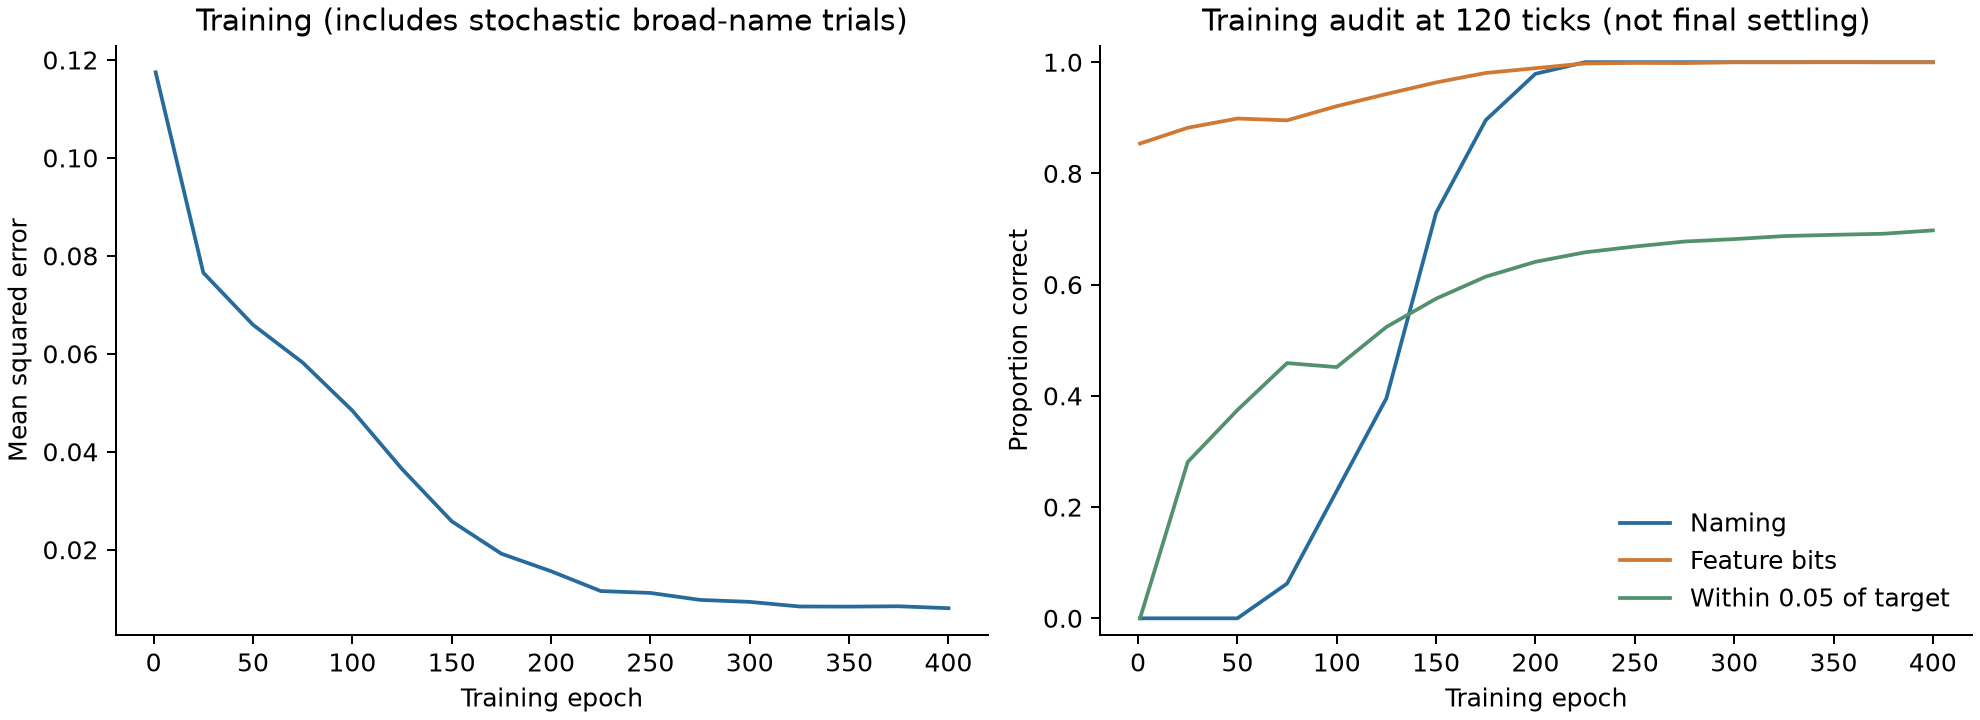

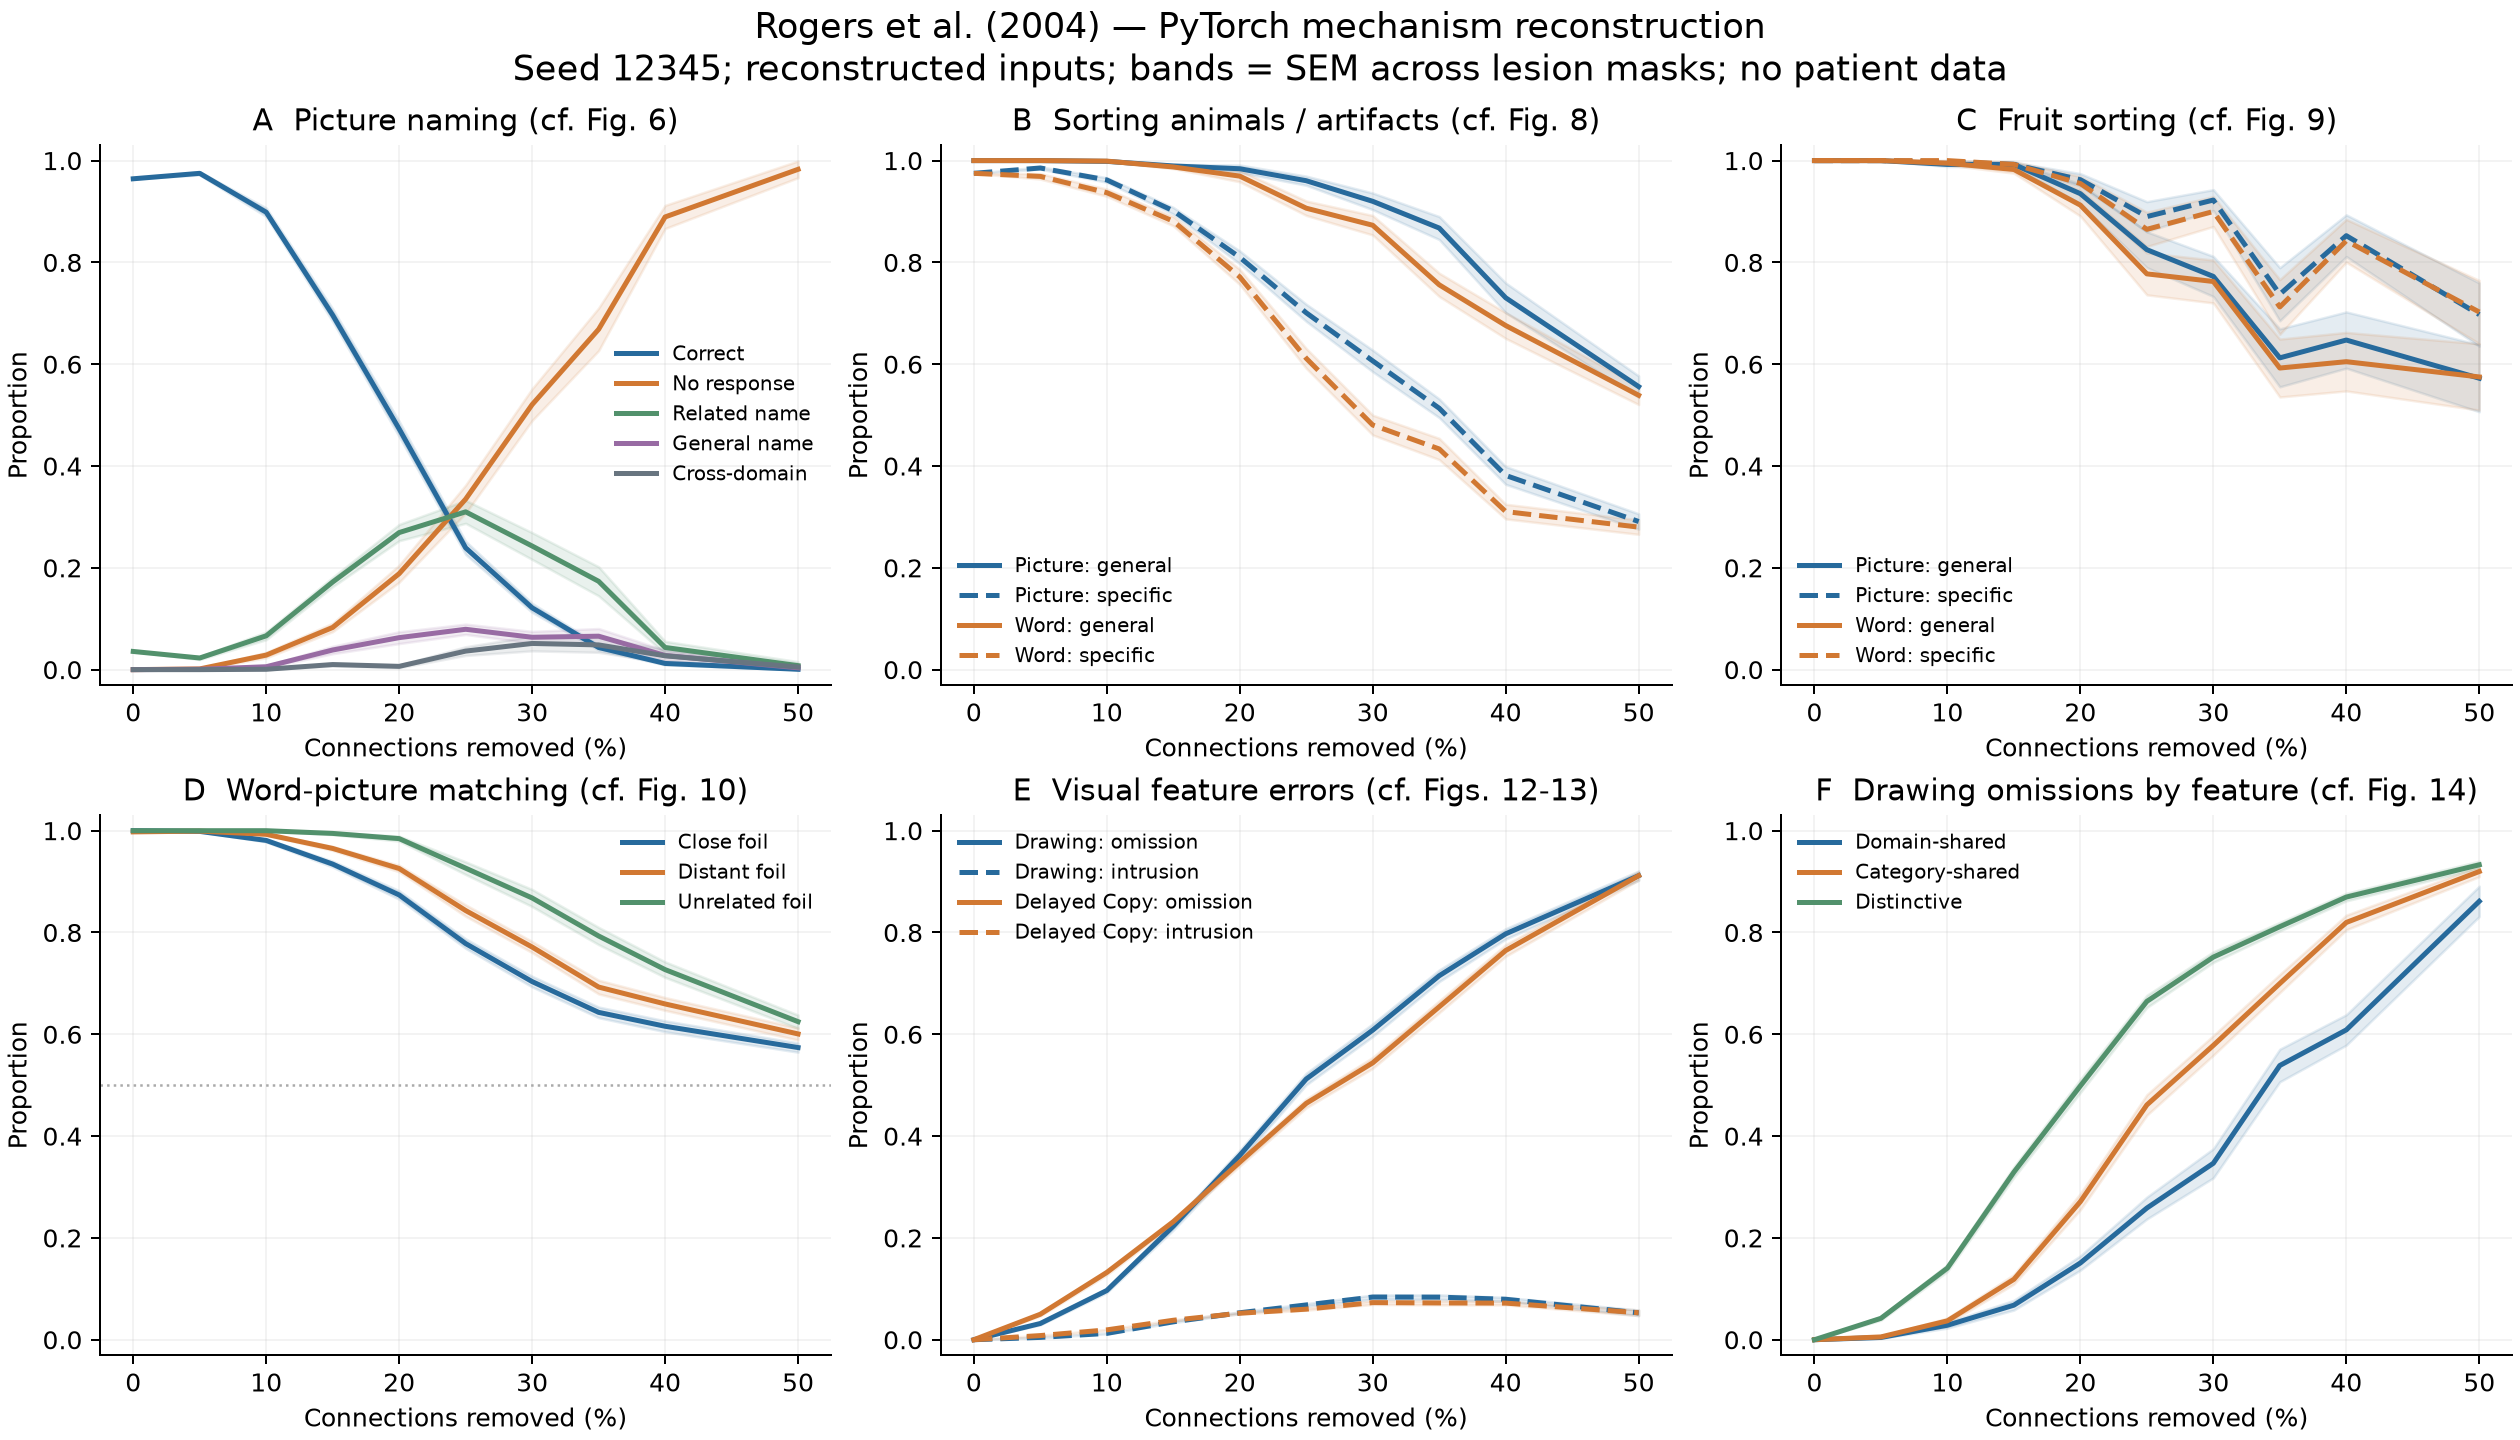

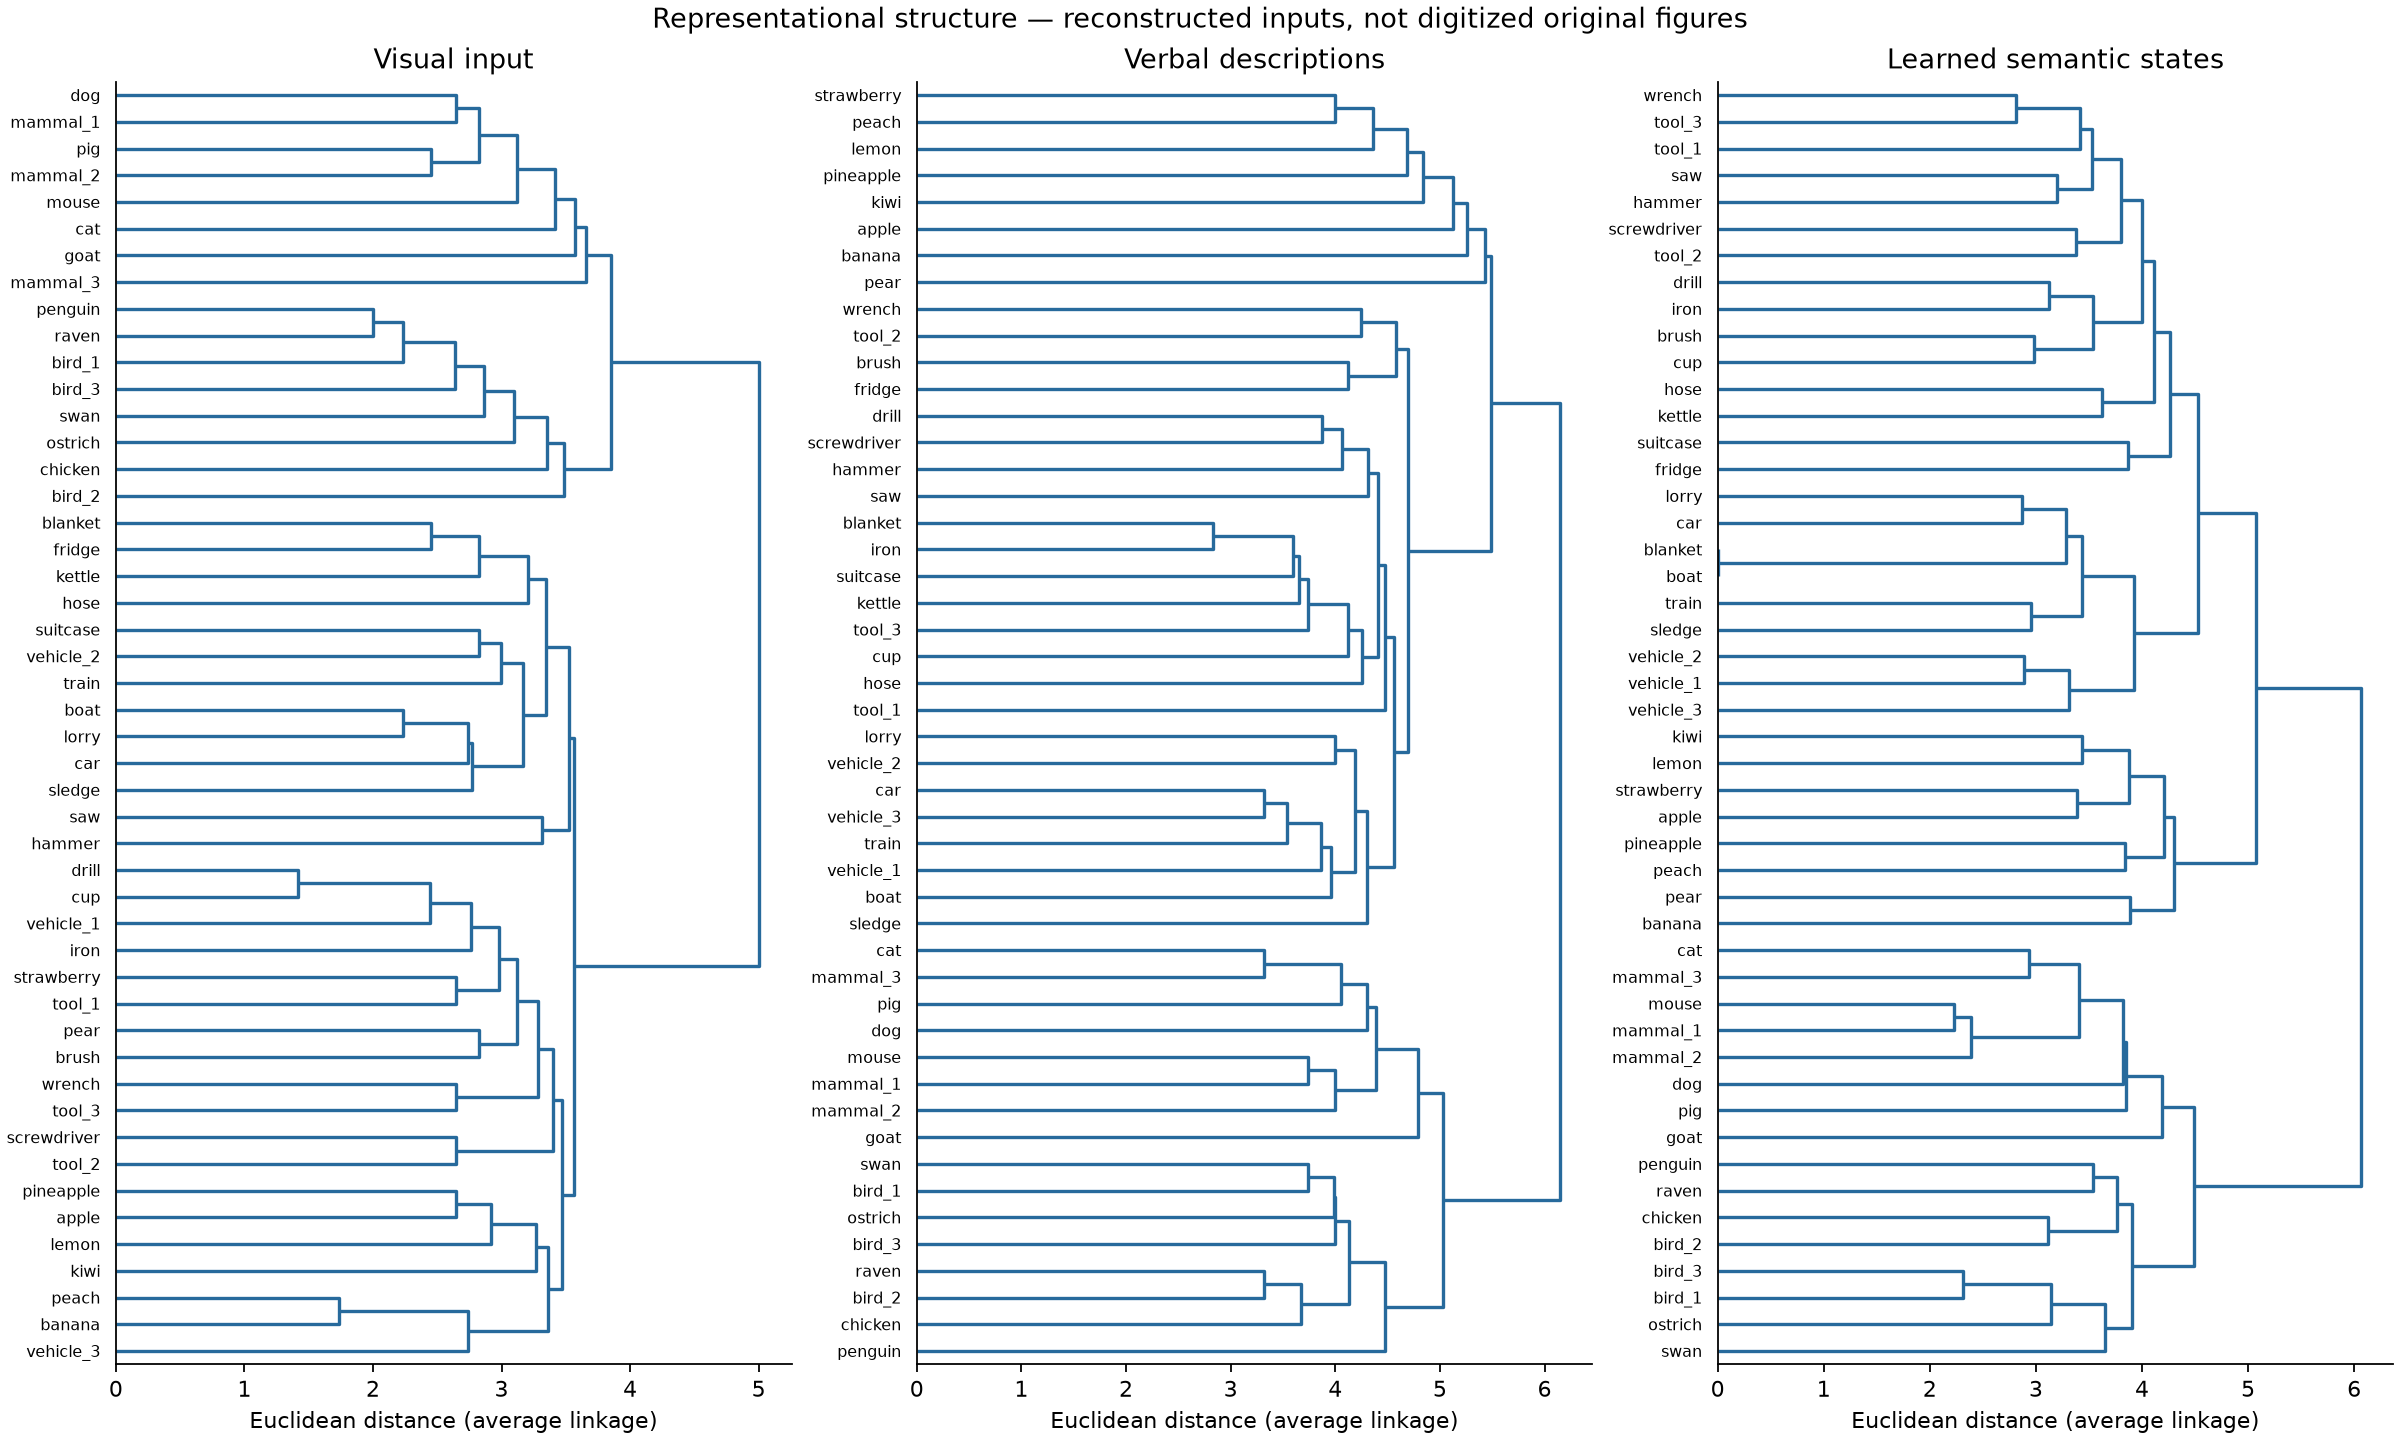

In [6]:
from IPython.display import display, Image, Markdown
plot_results(OUTPUT)
display(Image(filename=str(OUTPUT / 'training.png')))
display(Image(filename=str(OUTPUT / 'lesion_results.png')))
display(Image(filename=str(OUTPUT / 'representations.png')))

## 5. Compare predictions with actual outcomes

The generated report contains actual values beside qualitative expectations, including nonmatches. A successful simulation establishes a possible mechanism under these assumptions, not its uniqueness or biological truth.

In [7]:
display(Markdown((OUTPUT / 'RESULTS.md').read_text(encoding='utf8').split('![Training]')[0]))

# Measured reconstruction results

**This is a mechanism reconstruction with newly generated feature vectors, not an exact reproduction of the published curves.**

Training: seed=12345, data seed=2004, epochs=400, learning rate=0.005, gradient scale=1.0.

## Intact network

- naming_accuracy: 0.979167
- unique_naming_accuracy: 0.972222
- feature_bit_accuracy: 0.996773
- within_005_fraction: 0.695917
- max_error: 0.997143
- mse: 0.005764
- settle_residual: 0.000010
- settle_ticks: 1073.000000
- nonconvergent_inputs: 0.000000

Intact exact-naming criterion: NOT MET. All audited outputs within 0.05: NOT MET. Qualitative lesion effects below do not override these failures.

The within-0.05 audit excludes ambiguous general-name cues, whose targets vary by trial. It includes all visual and verbal cues. This fraction must not be confused with all units passing the paper criterion.

## Paper predictions compared with this run

| Measure | Actual simulation | Published qualitative expectation |
|---|---|---|
| Naming at 20% lesion | 0.473 | Declines with damage |
| Picture sorting: general minus specific (20%) | +0.174 | Positive |
| Fruit picture sorting: specific minus general (20%) | +0.027 | Positive (reversal) |
| Matching: close / distant / unrelated (20%) | 0.874 / 0.926 / 0.984 | Increasing |
| Drawing: distinctive minus domain-shared omissions (20%) | +0.348 | Positive |
| Drawing minus delayed-copy total errors (20%) | +0.047 | Positive; eligible items differ as in paper |

Maximum mean final-tick residual over lesion levels: 0.00147956. Evaluation allows up to 2000 ticks and stops after four consecutive updates smaller than 1e-5. Raw CSV includes nonconvergent input counts; capped trials must not be described as proven fixed points.

**Convergence limitation:** 50/451 trials reached the cap with at least one unsettled input; 40 had unsettled visual inputs. These trials remain in the plots (not silently discarded), so the curves are finite-time responses where convergence failed. The intact network has 0 unsettled inputs.

Earlier fixed-200-tick summaries are retained in `summary_200ticks.json` for the settling sensitivity check. The original training source is retained as `training_source.py`, matching the training hash in config.json. Final evaluation code has its own hash in evaluation_config.json.

Error bands are standard errors over lesion masks for one trained network. They are not patient uncertainty or between-training-seed uncertainty. No patient measurements were fabricated, digitized, or fitted.

See `notes/ROGERS2004_NOTES.md` for every reconstruction choice and known limitations.

